In [ ]:
import os
import sys

# Repository root, so that paths.py (DATA_DIR / RESULTS_DIR / FIGURES_DIR) can be imported.
sys.path.insert(0, os.path.abspath('../..'))
import paths

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

import sherlock as slk

In [2]:
concentration  = '1'
tcdg = 1000

In [3]:
data = sc.read_h5ad(f"{paths.DATA_DIR}/gbm/CDS_BT333_Tcells_0_cutoff.h5ad")

In [4]:
data = data[(data.obs['total_hash_umis_per_cell_ID']>1) & (data.obs['top_to_second_best_ratio']>2)].copy()

In [5]:
data.obs

,P7,P5,sample,n.umi,cell_ID,RT,Lig,new_cell,oligo,hash_umis,total_hash_umis_per_cell_ID,top_to_second_best_ratio,treatment,log10.umi,percent_mito
F01_A06_RT_BC_100_Lig_BC_12,F01,A06,BT333_Tcells,5598.0,F01_A06_RT_BC_100_Lig_BC_12,RT_BC_100,Lig_BC_12,A06_RT_BC_100_Lig_BC_12,EX2P13_Zabedosertib_1_NoT_R1_02B04,30,43,30.00,EX2P13_Zabedosertib_1_NoT,3.748033,0.0
F01_A06_RT_BC_100_Lig_BC_15,F01,A06,BT333_Tcells,1520.0,F01_A06_RT_BC_100_Lig_BC_15,RT_BC_100,Lig_BC_15,A06_RT_BC_100_Lig_BC_15,Ex2P11_SGCAAK11_1_0.5T_R3_01F06,6,24,3.00,Ex2P11_SGCAAK11_1_0.5T,3.181844,0.0
F01_A06_RT_BC_100_Lig_BC_20,F01,A06,BT333_Tcells,2339.0,F01_A06_RT_BC_100_Lig_BC_20,RT_BC_100,Lig_BC_20,A06_RT_BC_100_Lig_BC_20,Ex2P11_STK16IN1_0.1_0.5T_R1_01C02,11,43,5.50,Ex2P11_STK16IN1_0.1_0.5T,3.369030,0.0
F01_A06_RT_BC_100_Lig_BC_21,F01,A06,BT333_Tcells,9603.0,F01_A06_RT_BC_100_Lig_BC_21,RT_BC_100,Lig_BC_21,A06_RT_BC_100_Lig_BC_21,Ex2P11_Abemaciclibmesylate_0.01_0.5T_R2_01H01,61,78,30.50,Ex2P11_Abemaciclibmesylate_0.01_0.5T,3.982407,0.0
F01_A06_RT_BC_100_Lig_BC_23,F01,A06,BT333_Tcells,913.0,F01_A06_RT_BC_100_Lig_BC_23,RT_BC_100,Lig_BC_23,A06_RT_BC_100_Lig_BC_23,EX2P13_Zabedosertib_0.01_NoT_R1_02D04,16,45,8.00,EX2P13_Zabedosertib_0.01_NoT,2.960471,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
F12_H06_RT_BC_99_Lig_BC_77,F12,H06,BT333_Tcells,496.0,F12_H06_RT_BC_99_Lig_BC_77,RT_BC_99,Lig_BC_77,H06_RT_BC_99_Lig_BC_77,EX2P13_Taletrectinib_0.01_NoT_R2_02H09,3,12,3.00,EX2P13_Taletrectinib_0.01_NoT,2.695482,0.0
F12_H06_RT_BC_99_Lig_BC_86,F12,H06,BT333_Tcells,1033.0,F12_H06_RT_BC_99_Lig_BC_86,RT_BC_99,Lig_BC_86,H06_RT_BC_99_Lig_BC_86,EX1P11_Tyrphostin9_0.01_0.5T_R2_04D08,33,111,2.75,EX1P11_Tyrphostin9_0.01_0.5T,3.014100,0.0
F12_H06_RT_BC_99_Lig_BC_88,F12,H06,BT333_Tcells,1693.0,F12_H06_RT_BC_99_Lig_BC_88,RT_BC_99,Lig_BC_88,H06_RT_BC_99_Lig_BC_88,Ex2P11_SGCAAK11_0.01_0.5T_R3_01H06,10,17,10.00,Ex2P11_SGCAAK11_0.01_0.5T,3.228657,0.0
F12_H06_RT_BC_99_Lig_BC_93,F12,H06,BT333_Tcells,10.0,F12_H06_RT_BC_99_Lig_BC_93,RT_BC_99,Lig_BC_93,H06_RT_BC_99_Lig_BC_93,Ex2P11_PF06260933_0.1_0.5T_R2_01G05,7,8,7.00,Ex2P11_PF06260933_0.1_0.5T,1.000000,0.0


In [6]:
data = data[data.obs['n.umi' ]>500].copy()
data

AnnData object with n_obs × n_vars = 106721 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'hash_umis', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'log10.umi', 'percent_mito'
    var: 'features'

In [7]:
data.obs.treatment

F01_A06_RT_BC_100_Lig_BC_12               EX2P13_Zabedosertib_1_NoT
F01_A06_RT_BC_100_Lig_BC_15                  Ex2P11_SGCAAK11_1_0.5T
F01_A06_RT_BC_100_Lig_BC_20                Ex2P11_STK16IN1_0.1_0.5T
F01_A06_RT_BC_100_Lig_BC_21    Ex2P11_Abemaciclibmesylate_0.01_0.5T
F01_A06_RT_BC_100_Lig_BC_23            EX2P13_Zabedosertib_0.01_NoT
                                               ...                 
F12_H06_RT_BC_99_Lig_BC_60           EX1P11_Taletrectinib_0.01_0.5T
F12_H06_RT_BC_99_Lig_BC_63      EX1P11_Abemaciclibmesylate_0.01_NoT
F12_H06_RT_BC_99_Lig_BC_86             EX1P11_Tyrphostin9_0.01_0.5T
F12_H06_RT_BC_99_Lig_BC_88                Ex2P11_SGCAAK11_0.01_0.5T
F12_H06_RT_BC_99_Lig_BC_95        EX1P11_Abemaciclibmesylate_10_NoT
Name: treatment, Length: 106721, dtype: object

In [8]:
# Parse treatment column into separate components
# Format: Experiment_Drug_Concentration_TcellTreatment
treatment_split = data.obs['treatment'].str.split('_', n=3, expand=True)

# Assign to new columns
data.obs['experiment'] = treatment_split[0]
data.obs['drug'] = treatment_split[1]
data.obs['concentration'] = treatment_split[2]
data.obs['tcell_treatment'] = treatment_split[3]

# Display the parsed columns
print("Parsed treatment components:")
print(data.obs[['treatment', 'experiment', 'drug', 'concentration', 'tcell_treatment']].head(10))
print(f"\nUnique experiments: {data.obs['experiment'].nunique()}")
print(f"Unique drugs: {data.obs['drug'].nunique()}")
print(f"Unique concentrations: {data.obs['concentration'].nunique()}")
print(f"Unique T cell treatments: {data.obs['tcell_treatment'].nunique()}")

Parsed treatment components:
                                                        treatment experiment  \
F01_A06_RT_BC_100_Lig_BC_12             EX2P13_Zabedosertib_1_NoT     EX2P13   
F01_A06_RT_BC_100_Lig_BC_15                Ex2P11_SGCAAK11_1_0.5T     Ex2P11   
F01_A06_RT_BC_100_Lig_BC_20              Ex2P11_STK16IN1_0.1_0.5T     Ex2P11   
F01_A06_RT_BC_100_Lig_BC_21  Ex2P11_Abemaciclibmesylate_0.01_0.5T     Ex2P11   
F01_A06_RT_BC_100_Lig_BC_23          EX2P13_Zabedosertib_0.01_NoT     EX2P13   
F01_A06_RT_BC_100_Lig_BC_34        EX1P11_Taletrectinib_0.01_0.5T     EX1P11   
F01_A06_RT_BC_100_Lig_BC_49           Ex2P11_PF06260933_0.01_0.5T     Ex2P11   
F01_A06_RT_BC_100_Lig_BC_54                     EX1P11_DMSO_0_NoT     EX1P11   
F01_A06_RT_BC_100_Lig_BC_58                Ex2P11_SGCAAK11_1_0.5T     Ex2P11   
F01_A06_RT_BC_100_Lig_BC_65          EX1P11_Laduviglusib_0.1_0.5T     EX1P11   

                                            drug concentration tcell_treatment  
F01_A06_R

In [9]:
# Select only concentration of 1 from all drugs and add DMSO control
control_data = data[
    (data.obs['concentration'] == concentration) | (data.obs['drug'] == 'DMSO')
].copy()

In [10]:
control_data = control_data[control_data.obs['tcell_treatment']=="NoT"].copy()

In [11]:
sc.pp.normalize_total(control_data)
sc.pp.log1p(control_data)
sc.pp.pca(control_data)

sc.tl.rank_genes_groups(
    control_data, groupby='drug', reference='DMSO',
    use_raw=False, method='wilcoxon'
)

In [12]:
# Long-form results across all groups
df = sc.get.rank_genes_groups_df(control_data, group=None, key='rank_genes_groups')

# Raw p-value < 0.05
sig_raw = (df.loc[df['pvals'] < 0.05]
             .sort_values(['group','pvals'])
             .reset_index(drop=True))

# Adjusted p-value (FDR) < 0.05 (recommended)
sig_adj = (df.loc[df['pvals_adj'] < 0.05]
             .sort_values(['group','pvals_adj'])
             .reset_index(drop=True))

# Per-group lists (raw p)
deg_by_group_raw = (sig_raw.groupby('group')['names'].apply(list).to_dict())

# Per-group lists (FDR)
deg_by_group_adj = (sig_adj.groupby('group')['names'].apply(list).to_dict())

# Unique gene sets
unique_deg_raw = sorted(sig_raw['names'].unique().tolist())
unique_deg_adj = sorted(sig_adj['names'].unique().tolist())

print("\nCounts (FDR<0.05) per group:")
print(sig_adj.groupby('group').size())


Counts (FDR<0.05) per group:
group
ALWII4127               50
Abemaciclibmesylate    257
BAY1217389               4
CP673451                60
Laduviglusib             3
PF06260933               0
SGCAAK11                 2
STK16IN1                19
Taletrectinib            3
Tyrphostin9            341
Zabedosertib            14
dtype: int64


/tmp/ipykernel_3113689/3292257313.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deg_by_group_raw = (sig_raw.groupby('group')['names'].apply(list).to_dict())
/tmp/ipykernel_3113689/3292257313.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deg_by_group_adj = (sig_adj.groupby('group')['names'].apply(list).to_dict())
/tmp/ipykernel_3113689/3292257313.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sig

In [13]:
data

AnnData object with n_obs × n_vars = 106721 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'hash_umis', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'log10.umi', 'percent_mito', 'experiment', 'drug', 'concentration', 'tcell_treatment'
    var: 'features'

In [14]:
deg_genes = df[df['pvals_adj'] < 0.05]['names'].unique()

In [15]:
len(deg_genes)

569

In [16]:
data.obs['tcell_treatment']

F01_A06_RT_BC_100_Lig_BC_12     NoT
F01_A06_RT_BC_100_Lig_BC_15    0.5T
F01_A06_RT_BC_100_Lig_BC_20    0.5T
F01_A06_RT_BC_100_Lig_BC_21    0.5T
F01_A06_RT_BC_100_Lig_BC_23     NoT
                               ... 
F12_H06_RT_BC_99_Lig_BC_60     0.5T
F12_H06_RT_BC_99_Lig_BC_63      NoT
F12_H06_RT_BC_99_Lig_BC_86     0.5T
F12_H06_RT_BC_99_Lig_BC_88     0.5T
F12_H06_RT_BC_99_Lig_BC_95      NoT
Name: tcell_treatment, Length: 106721, dtype: object

In [17]:
DMSO_data = data[data.obs['drug'] =="DMSO"].copy()

In [18]:
sc.pp.normalize_total(DMSO_data)
sc.pp.log1p(DMSO_data)
sc.pp.pca(DMSO_data)

sc.tl.rank_genes_groups(
    DMSO_data, groupby='tcell_treatment', reference='NoT',
    use_raw=False, method='wilcoxon'
)

In [19]:
df = sc.get.rank_genes_groups_df(DMSO_data, group=None, key='rank_genes_groups')
df

,names,scores,logfoldchanges,pvals,pvals_adj
0,STAT1,69.185791,2.239670,0.000000e+00,0.000000e+00
1,GBP1,66.137337,3.626599,0.000000e+00,0.000000e+00
2,WARS,65.270439,2.934121,0.000000e+00,0.000000e+00
3,PARP14,65.074768,2.785440,0.000000e+00,0.000000e+00
4,IRF1,60.541553,3.071109,0.000000e+00,0.000000e+00
...,...,...,...,...,...
56643,FREM2,-33.531273,-1.071014,1.688207e-246,3.415483e-243
56644,PTPRD,-36.002625,-1.243335,7.610498e-284,1.796331e-280
56645,SOX2-OT,-40.061810,-1.440644,0.000000e+00,0.000000e+00
56646,PTPRZ1,-44.747593,-1.054011,0.000000e+00,0.000000e+00


In [20]:
# top 100 T cell genes by sorting absolute scores and take top 100
df['abs_score'] = df['scores'].abs()
tcell_genes = df.sort_values('abs_score', ascending=False).head(tcdg)['names'].unique()  

In [21]:
tcell_genes

array(['STAT1', 'GBP1', 'WARS', 'PARP14', 'IRF1', 'HLA-E', 'RNF213',
       'HLA-B', 'ADGRV1', 'GBP2', 'CD74', 'PTPRZ1', 'OAS3', 'AC016831.1',
       'TAP1', 'SOX2-OT', 'PML', 'CIITA', 'NLRC5', 'MT2A', 'TAPBP',
       'SOD2', 'CXCL10', 'PTPRD', 'A2M', 'TNC', 'IFI6', 'FREM2', 'NEAT1',
       'STAT2', 'APOL6', 'ICAM1', 'SAMD9L', 'IFITM3', 'B2M', 'LSAMP',
       'ADGRE5', 'IL32', 'NRG1', 'HLA-DRA', 'CLIP1', 'GBP4', 'CSF1',
       'XAF1', 'MAP2', 'ITGA3', 'SERPING1', 'FRMD4A', 'CXCL9', 'SOX5',
       'REV3L', 'TRIM2', 'LAP3', 'LINC00511', 'SAMHD1', 'ZC3HAV1',
       'DDX58', 'LGALS3BP', 'SP100', 'ETV6', 'HLA-A', 'CXCL11', 'APOL2',
       'COL6A1', 'COL6A2', 'NCAM1', 'IFI44L', 'PKM', 'BST2', 'LDLR',
       'CTSS', 'LHFPL6', 'ST8SIA5', 'LHFPL3', 'PXDN', 'SOX6', 'ADAR',
       'RNF19A', 'IGFBP5', 'CHI3L1', 'SAMD4A', 'GBP3', 'TMSB10', 'NRCAM',
       'MIR4435-2HG', 'IL18BP', 'MAP3K1', 'IFIT3', 'SPRED1', 'MSI2',
       'TUBA1A', 'JAK2', 'ADGRB3', 'OAS2', 'ZNFX1', 'APOL1', 'FARP1',
       'ZNF70

In [22]:
# make sets (cast to str to avoid dtype issues)
deg_set = set(map(str, deg_genes))
tcell_set = set(map(str, tcell_genes))

union_set = deg_set.union(tcell_set)
union_list = sorted(union_set)

print(f"Drug DEGs:        {len(deg_set)} genes")
print(f"T-cell DEGs:      {len(tcell_set)} genes")
print(f"Union:            {len(union_set)} genes")

Drug DEGs:        569 genes
T-cell DEGs:      1000 genes
Union:            1320 genes


In [23]:
data = data[:, union_list].copy()

In [24]:
data.var.rename(columns={'_index':'index'},inplace=True)
data.raw.var.rename(columns={'_index':'index'},inplace=True)

In [25]:
data

AnnData object with n_obs × n_vars = 106721 × 1320
    obs: 'P7', 'P5', 'sample', 'n.umi', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'hash_umis', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'log10.umi', 'percent_mito', 'experiment', 'drug', 'concentration', 'tcell_treatment'
    var: 'features'

In [242]:
data.write_h5ad(f"{paths.DATA_DIR}/gbm/bt333_degs_tcell_{concentration}_{tcdg}.h5ad")

# plot umaps before sherlock

In [24]:
concentration  = '10'
tcdg = 1000

In [25]:
# read in processed data
data = sc.read_h5ad(f"{paths.DATA_DIR}/gbm/bt333_degs_tcell_{concentration}_{tcdg}.h5ad")

In [26]:

# remove na from drug column
data = data[~data.obs['drug'].isna()].copy()
data = data[
    (data.obs['concentration'] == concentration) | (data.obs['drug'] == 'DMSO')
].copy()

In [ ]:
sc.pp.normalize_total(data)
sc.pp.log1p(data)
sc.pp.pca(data, random_state=0)

sc.pp.neighbors(data, random_state=0)
sc.tl.umap(data, random_state=0)


In [28]:
figure_dir = f"{paths.FIGURES_DIR}/kinase_inhibitors_tcell/"
os.makedirs(figure_dir, exist_ok=True)

In [29]:
data

AnnData object with n_obs × n_vars = 35511 × 2894
    obs: 'P7', 'P5', 'sample', 'n.umi', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'hash_umis', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'log10.umi', 'percent_mito', 'experiment', 'drug', 'concentration', 'tcell_treatment'
    var: 'features'
    uns: 'log1p', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [ ]:
# new_colormap = [
# "#FFD166",  
# "#023047", 
# "#EF476F",  
# "#06D6A0",  
# "#8338EC",  
# "#FFBE0B",  
# "#FB5607",  
# "#3A86FF",  
# "#FF006E",  
# "#00D9FF",  
# "#38A169" 
# ]

/home/user/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/tmp/ipykernel_3919940/1752065588.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


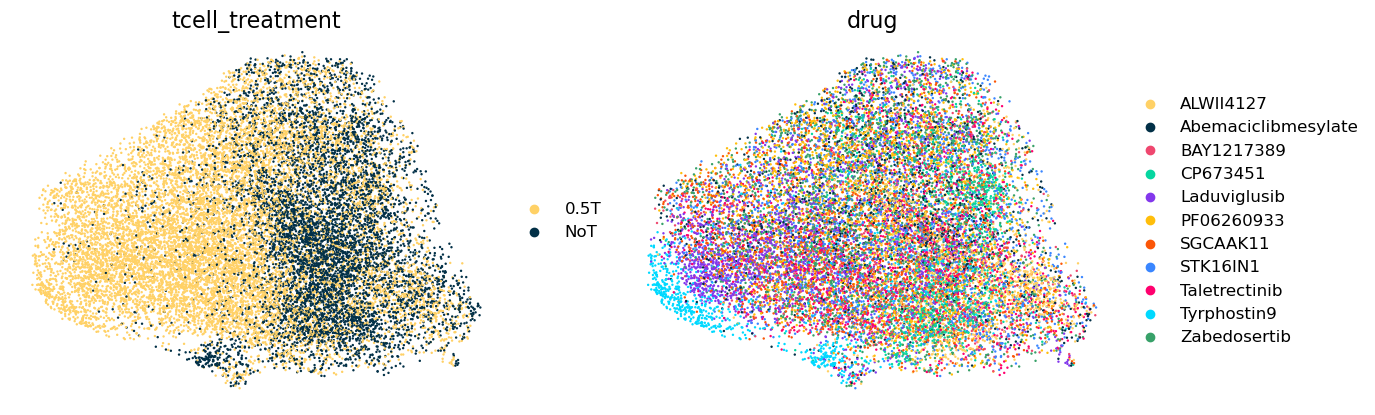

In [ ]:
# import matplotlib as mpl
# mpl.rcParams.update({'font.size': 12, 'svg.fonttype': 'none'})
# mpl.rcParams['axes.titlesize'] = 16
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['axes.labelsize'] = 12
# mpl.rcParams['lines.linewidth'] = 2

# fig = sc.pl.umap(data[data.obs['drug'] != 'DMSO'], color=['tcell_treatment', 'drug'], 
#                    s=12, frameon=False, show=False, palette=new_colormap)

# plt.tight_layout()
# plt.savefig(os.path.join(figure_dir, f"{concentration}_umaps.svg"), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(figure_dir, f"{concentration}_umaps.png"), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(figure_dir, f"{concentration}_umaps.pdf"), dpi=300, bbox_inches='tight')
# plt.show()

/home/user/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/user/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


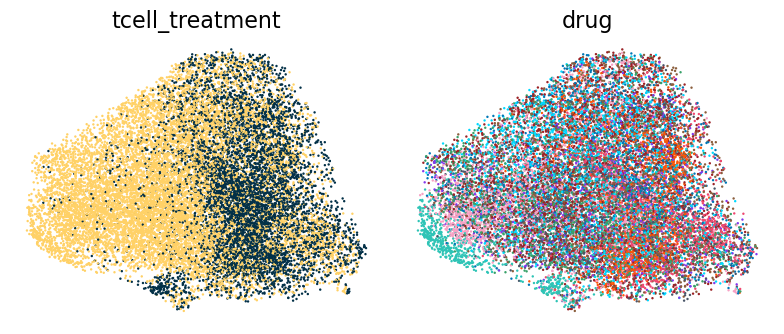

In [32]:
palette1 = [
"#FFD166",  
"#023047",  
]

palette2 = [
    "#EF476F", "#0077B6", "#8338EC", "#FB5607",  "#F7A1C4",
    "#00D9FF", "#38A169", "#8B5E3C", "#4A5568", "#2EC4B6", "#9B2226"
]

palette2_very_light = [
    "#EF476F",  # keep
    "#A8D8F0",  # very light blue
    "#D6C7FA",  # very light purple
    "#FB5607",  # keep
    "#FDD9E7",  # very light pink
    "#CFF5FF",  # very light cyan
    "#CDEEDD",  # very light green
    "#E3D2C4",  # very light brown
    "#D6DEE8",  # very light gray-blue
    "#CFF1EA",  # very light teal
    "#E8B3B3"   # very light dark red
]


import matplotlib as mpl
mpl.rcParams.update({'font.size': 12, 'svg.fonttype': 'none'})
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['lines.linewidth'] = 2

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

sc.pl.umap(data[data.obs['drug'] != 'DMSO'], color='tcell_treatment', title='tcell_treatment', 
           palette=palette1, size=12, frameon=False, ax=axes[0], show=False, legend_loc=None)

sc.pl.umap(data[data.obs['drug'] != 'DMSO'], color='drug', title='drug', 
           palette=palette2, size=12, frameon=False, ax=axes[1], show=False, legend_loc=None)

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, f"{concentration}_umaps.svg"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_umaps.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_umaps.pdf"), dpi=300, bbox_inches='tight')
plt.show()

/home/user/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/user/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


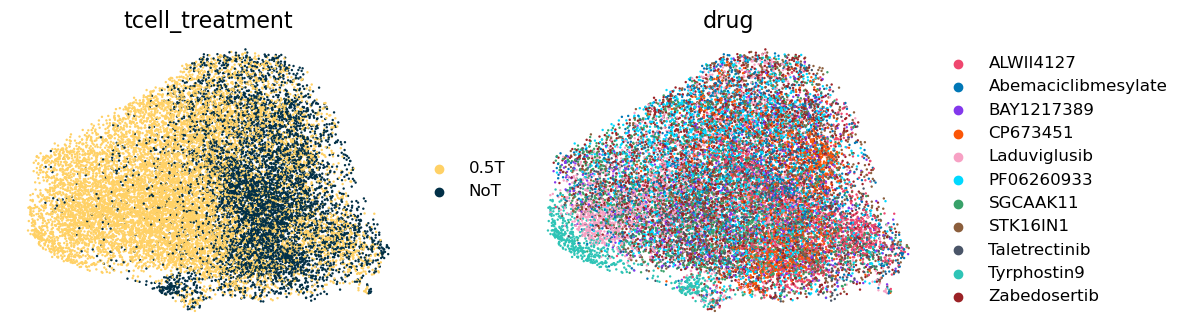

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

sc.pl.umap(data[data.obs['drug'] != 'DMSO'], color='tcell_treatment', title='tcell_treatment', 
           palette=palette1, size=12, frameon=False, ax=axes[0], show=False)

sc.pl.umap(data[data.obs['drug'] != 'DMSO'], color='drug', title='drug', 
           palette=palette2, size=12, frameon=False, ax=axes[1], show=False)

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, f"{concentration}_umaps_with_legends.svg"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_umaps_with_legends.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{concentration}_umaps_with_legends.pdf"), dpi=300, bbox_inches='tight')
plt.show()